In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

def load_dataset():
    df = pd.read_csv(DATA_URL, sep="\t", names=["label", "message"])
    return df

def preprocess_labels(df):
    df["label"] = df["label"].map({"ham":0, "spam":1})
    return df

def split_data(df, test_size=0.2, random_state=42):
    
    X = df["message"]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test

def get_processed_data():
    
    df = load_dataset()
    df = preprocess_labels(df)

    X_train, X_test, y_train, y_test = split_data(df)

    return X_train, X_test, y_train, y_test

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

NameError: name 'X_train' is not defined

In [3]:
X_train, X_test, y_train, y_test = get_processed_data()


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [5]:
X_train_dense = X_train_vec.toarray()
X_test_dense = X_test_vec.toarray()

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train_dense, y_train)

LinearDiscriminantAnalysis()

In [7]:
lda_pred = lda_model.predict(X_test_dense)

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [9]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, lda_pred))

Confusion Matrix:
[[964   2]
 [ 27 122]]


In [10]:
print("Accuracy:", accuracy_score(y_test, lda_pred))

Accuracy: 0.9739910313901345


In [11]:
print("Precision:", precision_score(y_test, lda_pred))

Precision: 0.9838709677419355


In [12]:
print("Recall:", recall_score(y_test, lda_pred))

Recall: 0.8187919463087249


In [13]:
print("F1 Score:", f1_score(y_test, lda_pred))

F1 Score: 0.8937728937728938


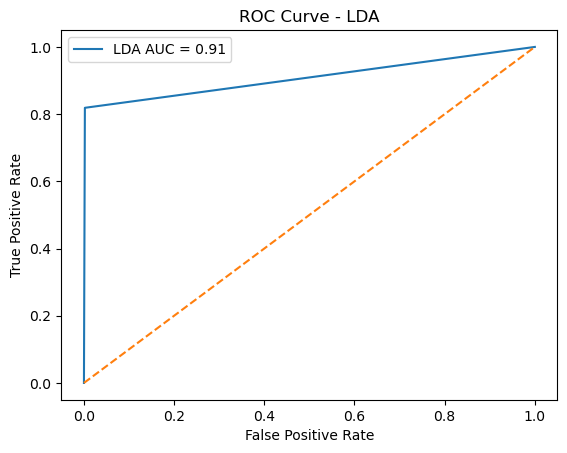

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

scores = lda_model.predict_proba(X_test_dense)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, scores)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="LDA AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LDA")
plt.legend()

plt.show()

In [15]:
import time

start = time.time()

lda_model.fit(X_train_dense, y_train)

train_time = time.time() - start

print("Training Time:", train_time)

Training Time: 74.85881304740906


In [16]:
start = time.time()

lda_pred = lda_model.predict(X_test_dense)

test_time = time.time() - start

print("Testing Time:", test_time)

Testing Time: 0.027768611907958984
